# Project 1: QUIC-Fire Maximum Spread
## Daryn Sagel <br>
For this project, I created a script that analyzes a pair of QUIC-Fire fuel density matrices and returns rates of spread of the burning/burned area. This script may return instantaneous or average rates of spread depending on whether matrices input to the script are sampled from consecutive timesteps. The maximum rate of spread is given as the first entry in this script's output, with all other rates of spread following in order of descending magnitude.<br><br>
To accomplish this, the burn area boundary must be calculated for each input matrix. After converting each fuel density matrix to a logical burn/no burn matrix, I use Delaunay triangulation to find an alpha shape (or alpha-concave hull) of burning/burned cells. The alpha shape approach is capable of appropriately identifying and outlining burn areas containing non-burned cells within. This is important for calculating less straightforward burning geometries, including ring fires or merging fire fronts. I selected the algorithm's user-input parameter, $\alpha$, empirically using QUIC-Fire outputs with one burning region, so further testing with multiple regions remains as possible future work. I also considered implementing a combined shared nearest neighbors (sNN) and k-nearest neighbors (kNN) approach to concave hull computation outlined by Moreira and Santos in the [2007 GRAPP conference proceedings](https://repositorium.sdum.uminho.pt/bitstream/1822/6429/1/ConcaveHull_ACM_MYS.pdf). The spatial cluster analysis steps provided by this method would extend the algorithm to detect multiple burn areas within the same fuel density matrix. Incorporating a similar cluster analysis step (through sNN, centroid clustering, or some version of DBSCAN) to the existing code would allow for multi-region calculations.<br><br>
<em>Notes for implementation:<br>(1) The boundary calculation code is packaged below as a standalone function so that it may be used more efficiently than it would inside an all-encompassing boundary + spread function for matrix pairs. This eliminates redundant boundary calculations for matrices in a sequence (e.g., finding the spread from $t_0$ &rarr; $t_1$ and then $t_1$ &rarr; $t_2$ requires calculating the boundary of $t_1$ only once).<br>(2) Changing the value of $\alpha$ results in less exact boundary polygons. This may be of interest to someone who wants to trade a reduction in exactness for a reduction in the number of boundary points, which should increase the speed of subsequent calculations.</em><br><br>
Spread rate is approximated for each boundary point in the second input matrix by finding the closest boundary point in the first input matrix. This is calculated as a simple matching between each point in the second boundary set with its closest neighbor in the first boundary set. I recommend that additional thought is given to also selecting point pairs based on the smallest angle between them in cases when there are multiple equidistant closest neighbors.<br><br>
Finally, the code returns a 2D array with (x,y) coordinates from the first and second set of boundary points, the magnitude of the spread, and the direction of spread in degrees relative to N in the format `(start point x, start point y, end point x, end point y, magnitude,` and `direction)`. Note that the magnitude is inherently returned as pixels, or cells, per timestep because the specific dimensions depend on user choice of QUIC-Fire output and simulated time between the matrix pair.<br><br>
### Packages
All required packages are in NumPy and SciPy, which are both already available within the QUIC-Fire framework. Matplotlib is included in this document for the sole purpose of illustrating how the example works, but is not used in the actual method.

In [5]:
import numpy as np
from scipy.spatial import Delaunay
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
# import bp3d

ModuleNotFoundError: No module named 'bp3d'

### Definitions

In [3]:
def fueldens_to_burnindex(arr):
    # Function to convert a fuel density array into a burn index array, modified to eliminate unnecessary computations
    # Input: (nt,nx,ny,nz) fuel density array
    # Output: (nt,nx,ny,nz) burn index array
    temp = np.divide(arr,arr[0,:,:,:][np.newaxis,:,:,:],out=np.zeros_like(arr), where=arr[0,:,:,:] != 0 )
    burn_index = np.ones_like(temp)
    burn_index *= 1
    burn_index[np.where(temp>0.99)] = 0
    return burn_index

def burnindex_to_coords(arr, t, fl):
    # Function to exclude hard-coded 1-px boundary and obtain coordinates of remaining burning/burned (nonzero) points
    # Input: (nx,ny) burn index array, timestep t, and fuel layer
    # Output: list of burning/burned coordinates with length(nx)
    arr = arr[t,1:arr.shape[1]-1,1:arr.shape[2]-1,fl]
    return np.transpose(np.nonzero(arr))


def get_centroid(arr):
    # Function to calculate the centroid of a group of points
    # DRG Comment: Is this relying on a square domain?
    # Input: (n,2) list of burning/burned area's coordinates
    # Output: pair of x,y coordinates of the centroid
    length = arr.shape[0]
    sum_x = np.sum(arr[:, 0])
    sum_y = np.sum(arr[:, 1])
    return sum_x/length, sum_y/length

def alpha_shape(points, alpha, only_outer=True):
    # Function to calculate the burning/burned area's alpha shape/alpha-concave hull
    # Input: (n,2) list of burning/burned coordinates, alpha parameter, and a boolean to determine whether only the outer border is
    #        returned or if inner edges of the shape are also returned
    #        Default only_outer is currently set to True, but the default should be changed to False if handling complex geometries
    #        or merging fire fronts.
    # Output: set of (i,j) indices in the input array that correspond to the alpha-shape boundary
    # Note -- At least four points are required for this algorithm to work.
    
    assert points.shape[0] > 3, "Need at least four points"

    def add_edge(edges, i, j):
        if (i, j) in edges or (j, i) in edges:
            # Already added
            assert (j, i) in edges, "Can't go twice over same directed edge right?"
            if only_outer:
                # If both neighboring triangles are in shape, it's not a boundary edge
                edges.remove((j, i))
            return
        edges.add((i, j))

    tri = Delaunay(points)
    edges = set()
    # Loop over triangles:
    # ia, ib, ic = indices of corner points of the triangle
    for ia, ib, ic in tri.simplices:
        pa = points[ia]
        pb = points[ib]
        pc = points[ic]
        # Computing radius of triangle circumcircle
        # www.mathalino.com/reviewer/derivation-of-formulas/derivation-of-formula-for-radius-of-circumcircle
        a = np.sqrt((pa[0] - pb[0]) ** 2 + (pa[1] - pb[1]) ** 2)
        b = np.sqrt((pb[0] - pc[0]) ** 2 + (pb[1] - pc[1]) ** 2)
        c = np.sqrt((pc[0] - pa[0]) ** 2 + (pc[1] - pa[1]) ** 2)
        s = (a + b + c) / 2.0
        area = np.sqrt(s * (s - a) * (s - b) * (s - c))
        circum_r = a * b * c / (4.0 * area)
        if circum_r < alpha:
            add_edge(edges, ia, ib)
            add_edge(edges, ib, ic)
            add_edge(edges, ic, ia)
    return edges

def boundary_coords(arr, centroid, a=1):
    # Function to convert the alpha_shape output into x,y coordinates
    # Coordinates are shifted to be consistent with compass orientation
    # Input: (nx,ny) burn index array and the alpha shape parameter, default to 1
    # Output: x,y coordinates of the boundary
    temp = []
    arr[:,0] = arr[:,0] - centroid[0]
    arr[:,1] = arr[:,1] - centroid[1]
    edges = alpha_shape(arr, alpha=1, only_outer=True)
    for i, j in edges:
        temp.append([arr[i, 1], arr[i, 0]])
    temp = np.array(temp)
    temp = temp[temp[:, 0].argsort()]  # sort by x
    temp = temp[temp[:, 1].argsort(kind='mergesort')]  # sort by y
    temp = np.flip(temp,axis=0)
    return temp


def match_points(xy1, xy2):
    # Function to match points between boundaries
    # Input: two sets of x,y boundary coordinates of the same length
    # Output: matching array stores as [x1 y1 x2 y2 magRoS angRoS_N]
    #         where angRoS_N is the angle of the end point per pair relative to y-axis (North)
    C = cdist(xy1,xy2) #1st entry determines row, 2nd entry determines col
    matching = []
    for c in range(C.shape[1]):
        r = np.argmin(C[:,c])
        px1 = xy1[r,0]
        py1 = xy1[r,1]
        px2 = xy2[c,0]
        py2 = xy2[c,1]
        angRoS_N = np.arctan2(xy2[c,1],xy2[c,0])*180/np.pi+90
        matching.append([px1, py1, px2, py2, C[r,c], angRoS_N])
        
    matching = np.unique(matching,axis=0)
    matching = matching[matching[:, 4].argsort()[::-1]]
    return matching
    
def calculate_ros(fd_array,tsteps,dir_method='edge'):
    # Wrapper function to calculate rate of spread. 
    # Input: Fuel density array, timesteps, and options for direction of rate of spread calculation
    # Output: matching array stores as [x1 y1 x2 y2 magRoS angRoS_N]
    #         where angRoS_N is the angle of the end point per pair relative to y-axis (North)
    t1,t2 =  tsteps
    burn_idx = fueldens_to_burnindex(fd_array)
    a1 = burnindex_to_coords(burn_idx,t1,0)
    a2 = burnindex_to_coords(burn_idx,t2,0)
    a1_centroid = get_centroid(a1)
    a2_centroid = get_centroid(a2)
    a1 = boundary_coords(a1, a1_centroid)
    a2 = boundary_coords(a2, a1_centroid)
    matching = match_points(a1, a2)
    if dir_method == 'centroid':
        xy = np.asarray(a2_centroid)-np.asarray(a1_centroid)
        matching[:,-1] = np.arctan2(xy[1],xy[0])*180./np.pi  
    return matching  

### Example with Illustrations

In [4]:
# Load fire array. Dimensions are (13, 200, 200, 5) for (t, x, y, z).
# First z layer has fuels from 0m-1m, second layer has 1m-2m, and so on.
#f = np.load('Test_run.npy')

In [8]:

c = bp3d.Client(url='https://burnpro3d.sdsc.edu/api')
df = c.load_ensemble('../../../bp3d/doc/uniform-pgml/uniform-pgml-success.bp3d.json').df

def get_fuel_density(run_id):
    run = c.output(otype='quicfire', id= run_id)
    print ('ntimes, nz, nx, ny : ', run.zarr['fuels-dens'].shape)
    return  run.zarr['fuels-dens'] 

rand_int = np.random.randint(np.shape(df)[0])
run_id = df['run_id'].iloc[rand_int]
print ('Wind Speed: ',df['wind_speed'].iloc[rand_int])
print ('Wind Dir: ',df['wind_direction'].iloc[rand_int])
print ('FMC: ',df['surface_moisture'].iloc[rand_int])
f = get_fuel_density(run_id)
f = np.swapaxes(f,1,3)
f = np.swapaxes(f,1,2)

/usr/local/lib/python3.11/dist-packages/bp3d-0.1.0-py3.11.egg/bp3d/ensemble.py:265: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  self._df = pd.read_json(j['df'])


Exception: Method Not Allowed

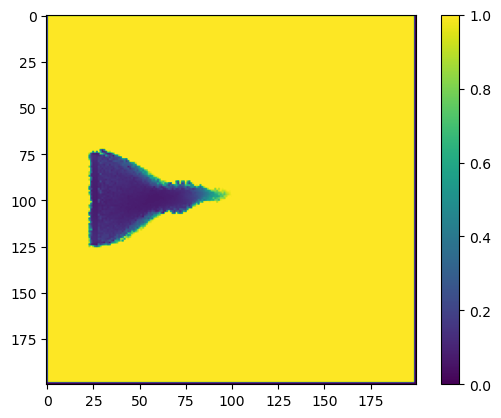

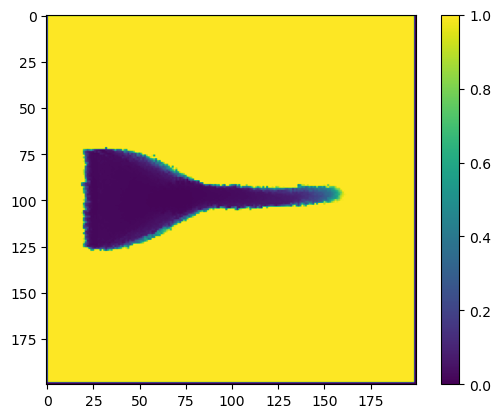

In [4]:
# I will calculate the spread between t=3 and t=10 for this example. Let's look at those.
burn_idx = fueldens_to_burnindex(f)
t1 = 2
t2 = 5
plt.imshow(f[t1,:,:,0])
plt.colorbar()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()
plt.imshow(f[t2,:,:,0])
plt.colorbar()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

In [5]:
# Using timesteps t=2 and t=5 and the first layer of fuel (0)
a1 = burnindex_to_coords(burn_idx,t1,0)
a2 = burnindex_to_coords(burn_idx,t2,0)

In [6]:
# Finding the centroid of the first shape (for later use)
a1_centroid = get_centroid(a1)

C:\Users\FireScience\AppData\Local\Temp\ipykernel_4800\3749677021.py:80: DeprecationWarning: Delaunay attribute 'vertices' is deprecated in favour of 'simplices' and will be removed in Scipy 1.11.0.
  edges = alpha_shape(arr, alpha=1, only_outer=True)


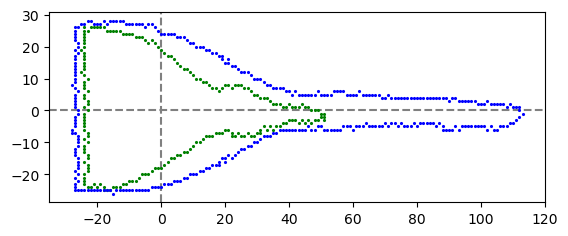

In [7]:
# Getting the boundary of each timestep relative to the centroid/North, South, East, West
a1 = boundary_coords(a1, a1_centroid)
a2 = boundary_coords(a2, a1_centroid)

plt.axvline(x=0, c="gray", ls='--')
plt.axhline(y=0, c="gray", ls='--')
plt.plot(a1[:,0], a1[:,1], 'g.', markersize=2.5)
plt.plot(a2[:,0], a2[:,1], 'b.', markersize=2.5)
plt.gca().set_aspect('equal', adjustable='box')

In [8]:
matching = match_points(a1, a2)

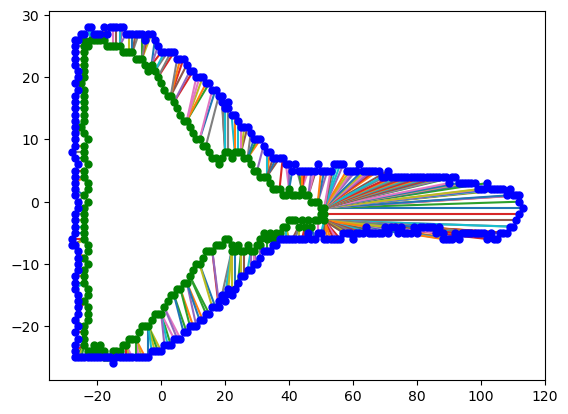

In [9]:
for i in range(np.shape(matching)[0]):
    plt.plot([matching[i,0],matching[i,2]],[matching[i,1],matching[i,3]]);
plt.plot(a1[:,0], a1[:,1], 'g.', markersize=10);
plt.plot(a2[:,0], a2[:,1], 'b.', markersize=10);

In [10]:
# Example of accessing values associated with highest rate of spread
print("Maximum RoS magnitude: ", matching[0, 4], "cells per timestep")
print("Maximum RoS direction: ", matching[0, 5], "degrees clockwise from North")
print("Maximum RoS start point: (", matching[0, 0], ",", matching[0, 1], ")")
print("Maximum RoS end point: (", matching[0, 2], ",", matching[0, 3], ")")

Maximum RoS magnitude:  62.0 cells per timestep
Maximum RoS direction:  89.49297093908523 degrees clockwise from North
Maximum RoS start point: ( 51.0 , -1.0 )
Maximum RoS end point: ( 113.0 , -1.0 )


### Code-only Example

In [14]:
'''
There are two methods to calculate the direction of maximal rate of spread which, depedent on the situation,
could be the appropriate method. 
The 'centroid' method takes the centroid point for each of the timesteps for which the ROS is being calculated
and calculates the angle between them. 
The 'edge' method takes the largest distance between the envelopes and uses the points associated with that 
calculated distance to get a direction of spread. 

DRG: I would recommend using the centroid method using the first timestep where the ignitions are done as the
initial timestep. This will ensure direction between different timesteps to be consistent and not too
sensitive to lurch or rapid fire motions on the perimeter. 
'''
# Setting up variables
f = np.load('Test_run.npy')
t1,t2 = 2,5

print ('Centroid ROS direction method')
matching =  calculate_ros(f,[t1,t2],dir_method='centroid')
# Example of accessing values associated with highest rate of spread
print("Maximum RoS magnitude: ", matching[0, 4], "cells per timestep")
print("Maximum RoS direction: ", matching[0, 5], "degrees clockwise from North")
print("Maximum RoS start point: (", matching[0, 0], ",", matching[0, 1], ")")
print("Maximum RoS end point: (", matching[0, 2], ",", matching[0, 3], ")")

print ('------------------------')
print ('Edge ROS direction method')
matching = calculate_ros(f,[t1,t2])
# Example of accessing values associated with highest rate of spread
print("Maximum RoS magnitude: ", matching[0, 4], "cells per timestep")
print("Maximum RoS direction: ", matching[0, 5], "degrees clockwise from North")
print("Maximum RoS start point: (", matching[0, 0], ",", matching[0, 1], ")")
print("Maximum RoS end point: (", matching[0, 2], ",", matching[0, 3], ")")

Centroid ROS direction method
Maximum RoS magnitude:  62.0 cells per timestep
Maximum RoS direction:  90.02305745485437 degrees clockwise from North
Maximum RoS start point: ( 51.0 , -1.0 )
Maximum RoS end point: ( 113.0 , -1.0 )
------------------------
Edge ROS direction method


C:\Users\FireScience\AppData\Local\Temp\ipykernel_4800\3749677021.py:80: DeprecationWarning: Delaunay attribute 'vertices' is deprecated in favour of 'simplices' and will be removed in Scipy 1.11.0.
  edges = alpha_shape(arr, alpha=1, only_outer=True)


Maximum RoS magnitude:  62.0 cells per timestep
Maximum RoS direction:  89.49297093908523 degrees clockwise from North
Maximum RoS start point: ( 51.0 , -1.0 )
Maximum RoS end point: ( 113.0 , -1.0 )
